In [5]:
import sys
sys.path.append('/workspaces/predictive-maintenance')

import pandas as pd
import numpy as np
from src.data_loader import load_data, add_rul

train, test, rul = load_data(data_dir='/workspaces/predictive-maintenance/data/raw/CMaps')
train = add_rul(train)

sensor_cols = [c for c in train.columns if c.startswith('sensor')]
std = train[sensor_cols].std()
print(std.sort_values())

sensor1     0.000000e+00
sensor10    0.000000e+00
sensor19    0.000000e+00
sensor18    0.000000e+00
sensor16    3.469531e-18
sensor5     5.329200e-15
sensor6     1.388985e-03
sensor15    3.750504e-02
sensor8     7.098548e-02
sensor13    7.191892e-02
sensor21    1.082509e-01
sensor20    1.807464e-01
sensor11    2.670874e-01
sensor2     5.000533e-01
sensor12    7.375534e-01
sensor7     8.850923e-01
sensor17    1.548763e+00
sensor3     6.131150e+00
sensor4     9.000605e+00
sensor14    1.907618e+01
sensor9     2.208288e+01
dtype: float64


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from data_loader import load_data, add_rul

In [8]:
train, test, rul = load_data(data_dir='../data/raw/CMaps')
train = add_rul(train)
print(train.shape)

(20631, 27)


In [9]:
sensor_cols = [c for c in train.columns if c.startswith('sensor')]

#calculate std for every sensor
std_df = train[sensor_cols].std().reset_index()
std_df.columns = ['sensor', 'std']
std_df = std_df.sort_values('std')

# automaticaly flg sensor blow a threshold as useless
THRESHOLD = 0.01
std_df['useful'] = std_df['std'] > THRESHOLD

print("USELESS SENSORE:")
print(std_df[std_df['useful'] == False]['sensor'].tolist())

print("\n=== USEFUL SENSORS ===")
print(std_df[std_df['useful'] == True]['sensor'].tolist())

USELESS SENSORE:
['sensor1', 'sensor10', 'sensor19', 'sensor18', 'sensor16', 'sensor5', 'sensor6']

=== USEFUL SENSORS ===
['sensor15', 'sensor8', 'sensor13', 'sensor21', 'sensor20', 'sensor11', 'sensor2', 'sensor12', 'sensor7', 'sensor17', 'sensor3', 'sensor4', 'sensor14', 'sensor9']


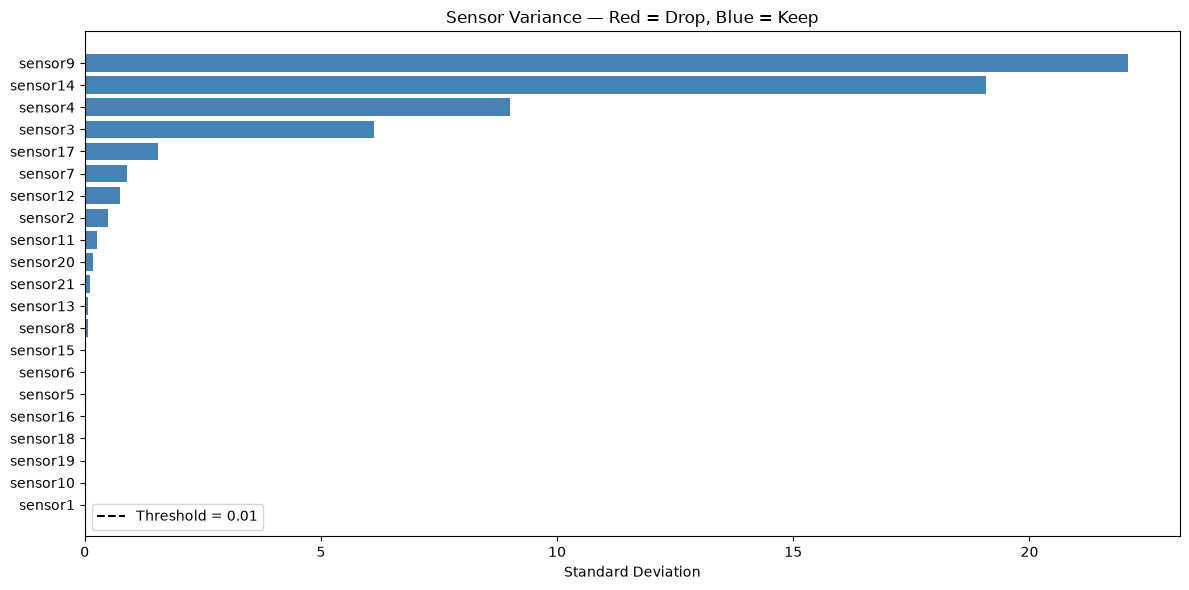

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['red' if not u else 'steelblue' for u in std_df['useful']]

ax.barh(std_df['sensor'], std_df['std'], color=colors)
ax.axvline(x=THRESHOLD, color='black', linestyle='--', label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Standard Deviation')
ax.set_title('Sensor Variance — Red = Drop, Blue = Keep')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/sensor_variance.png', dpi=150)
plt.show()